In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [14]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cuda')

In [15]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [16]:
# Interior points

N_f = 10000
x_f = np.random.uniform(0, L, N_f)
y_f = np.random.uniform(0, H, N_f)
t_f = np.random.uniform(0, T, N_f)

X_f = np.column_stack([x_f, y_f, t_f])
X_f = torch.tensor(
    X_f,
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

print(X_f.shape)


torch.Size([10000, 3])


In [17]:
# Generate wall points 

# Bottom boundary (x in [0, L], y=0, t in [0, T])
N_wall = 1000
x_bottom = np.linspace(0, L, N_wall)
bottom_pts = np.column_stack([
    x_bottom,
    np.zeros(N_wall),
    np.linspace(0, T, N_wall)
])

# Left boundary (x=0, y in [0, H], t in [0, T])
y_left = np.linspace(0, H, N_wall)
left_pts = np.column_stack([
    np.zeros(N_wall),
    y_left,
    np.linspace(0, T, N_wall)
])

# Right side wall (0->0.30, 0.70->1)
y_right_bottom_side = np.linspace(0, opening_y_min, N_wall // 2)
y_right_top_side = np.linspace(opening_y_max, H, N_wall // 2)

# (x=L, y=0->0.30, t in [0, T])
right_bottom_pts = np.column_stack([
    np.full(len(y_right_bottom_side), L),
    y_right_bottom_side,
    np.linspace(0, T, len(y_right_bottom_side))
])

# (x=L, y=0.70->1, t in [0, T])
right_top_pts = np.column_stack([
    np.full(len(y_right_top_side), L),
    y_right_top_side,
    np.linspace(0, T, len(y_right_top_side))
])


In [18]:
# Combining all wall points 
X_wall = np.vstack([left_pts, bottom_pts, right_bottom_pts, right_top_pts])
X_wall = torch.tensor(X_wall, dtype=torch.float32, device=device)
print(X_wall.shape)

torch.Size([3000, 3])


In [19]:
# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

torch.Size([500, 3])

In [20]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

In [21]:
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


tensor([[ 0.0288,  0.0239, -0.0375]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [22]:
print(pred[0,0].item())

0.02877393551170826


In [23]:
def derivatives(output, inputs):
    grad = torch.autograd.grad(
        output,
        inputs,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return grad

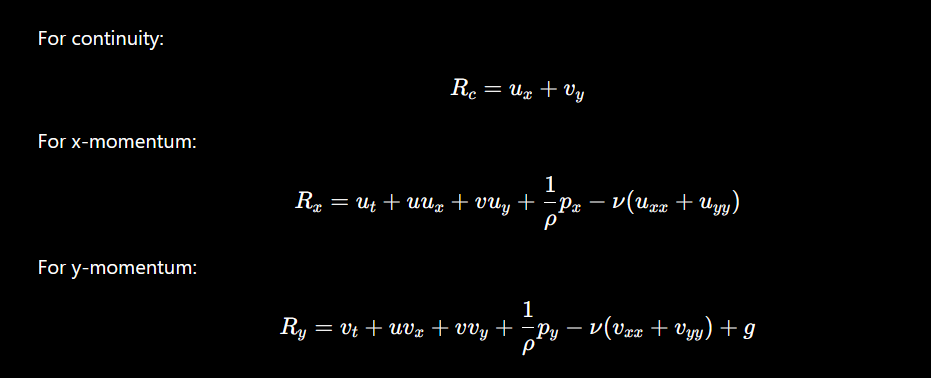

In [24]:
# continuity loss calculation
def continuity_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    # p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    v_y = derivatives(v, y)
    
    R_cont = u_x + v_y
    
    return R_cont

In [25]:
# x-momentum loss
def x_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    
    u_xx = derivatives(u_x, x)
    u_yy = derivatives(u_y, y)
    
    p_x = derivatives(p, x)

    u_t = derivatives(u, t)
    
    R_x = u_t + u*u_x + v*u_y + ((1/rho)*p_x) - nu*(u_xx + u_yy)
    
    return R_x

In [ ]:
# y-momentum loss
# NOTE: the network now predicts DYNAMIC pressure only.
# True pressure p = p_dynamic + p_hydrostatic, where p_hydrostatic = -rho*g*y
# so d(p_hydrostatic)/dy = -rho*g exactly cancels the gravity term below.
# This keeps the network's pressure output O(1) instead of needing to
# represent a ~-9810 Pa/m gradient, which was stalling the physics loss.
def y_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p_dynamic = pred[:, 2:3]
    
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)
    
    v_xx = derivatives(v_x, x)
    v_yy = derivatives(v_y, y)

    v_t = derivatives(v, t)
    
    p_y = derivatives(p_dynamic, y)
    
    R_y = v_t + u*v_x + v*v_y + (1/rho)*p_y - nu*(v_xx + v_yy)

    return R_y


In [30]:
print(X_f[:, 0], X_f[:, 1], X_f[:, 2])

tensor([0.7491, 1.9014, 1.4640,  ..., 1.8934, 0.7950, 0.4343], device='cuda:0',
       grad_fn=<SelectBackward0>) tensor([0.3736, 0.3329, 0.1762,  ..., 0.3037, 0.4433, 0.1723], device='cuda:0',
       grad_fn=<SelectBackward0>) tensor([0.7300, 0.1845, 0.3466,  ..., 0.0195, 0.4010, 0.2574], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [31]:
R_cont  = continuity_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_x     = x_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_y     = y_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])

print("Continuity residual:",
      R_cont.abs().mean().item())

print("X momentum residual:",
      R_x.abs().mean().item())

print("Y momentum residual:",
      R_y.abs().mean().item())

Continuity residual: 0.023813577368855476
X momentum residual: 0.01802227646112442
Y momentum residual: 9.807296752929688


In [32]:
def physics_loss():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)
    R_x = x_momentum_loss(model, x, y, t)
    R_y = y_momentum_loss(model, x, y, t)

    loss_cont = torch.mean(R_cont**2)
    loss_x = torch.mean(R_x**2)
    loss_y = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y

In [33]:
# Wall boundary loss (u=0, v=0)
def wall_loss():

    prediction = model(X_wall)

    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]

    loss_u = torch.mean(u_wall**2)
    loss_v = torch.mean(v_wall**2)

    return loss_u + loss_v

In [34]:
# Opening boundary condition (p=0)
def opening_loss():
    
    prediction = model(X_open)
    p_open = prediction[:, 2]

    return torch.mean(p_open**2)

In [35]:
X_pressure_ref = torch.tensor(
    [[0.0, H, 0.0]],
    dtype=torch.float32,
    device=device
)

def pressure_reference_loss():

    prediction = model(X_pressure_ref)
    p_ref = prediction[:, 2]

    return torch.mean(p_ref**2)

In [ ]:
# Initial condition points (t = 0, u = v = 0 everywhere in the domain)
N_ic = 2000
x_ic = np.random.uniform(0, L, N_ic)
y_ic = np.random.uniform(0, H, N_ic)
t_ic = np.zeros(N_ic)

X_ic = np.column_stack([x_ic, y_ic, t_ic])
X_ic = torch.tensor(X_ic, dtype=torch.float32, device=device)
print(X_ic.shape)

def ic_loss():
    pred = model(X_ic)
    u_ic = pred[:, 0]
    v_ic = pred[:, 1]
    return torch.mean(u_ic**2) + torch.mean(v_ic**2)


In [ ]:
# Total loss
# Loss weights -- tune these; wall/opening usually need to be weighted up
# relative to physics because rho=1000 makes physics-loss gradients dominate
lambda_phys = 1.0
lambda_wall = 10.0
lambda_open = 10.0
lambda_ref  = 1.0
lambda_ic   = 10.0

def total_loss():

    L_phys = physics_loss()
    L_wall = wall_loss()
    L_open = opening_loss()
    L_ref  = pressure_reference_loss()
    L_ic   = ic_loss()

    loss = (
        lambda_phys * L_phys +
        lambda_wall * L_wall +
        lambda_open * L_open +
        lambda_ref  * L_ref  +
        lambda_ic   * L_ic
    )

    return loss, L_phys, L_wall, L_open, L_ref, L_ic


## Complete Navier–Stokes momentum equation (full loss terms)

The blocks below extend the physics loss to match the full governing momentum equation shown in the reference image:

$$\frac{\partial u_i}{\partial t} + u_j\frac{\partial u_i}{\partial x_j} = -\frac{1}{\rho}\frac{\partial P}{\partial x_i} + \frac{\partial}{\partial x_j}\Big[\nu_{eff}\Big(\frac{\partial u_i}{\partial x_j} + \frac{\partial u_j}{\partial x_i}\Big)\Big] + g_i + \sigma k \frac{\partial \phi}{\partial x_i}$$

Term-by-term, compared with the simplified version used above (`x_momentum_loss`, `y_momentum_loss`):

- **Effective viscosity $\nu_{eff} = \nu + \nu_t$**: an LES (Smagorinsky) eddy-viscosity closure is added below (`eddy_viscosity`), so turbulent momentum transport is now included, not just molecular viscosity `nu`.
- **Full viscous stress tensor** $\frac{\partial}{\partial x_j}[\nu_{eff}(\partial u_i/\partial x_j + \partial u_j/\partial x_i)]$: replaces the simplified Laplacian `nu*(u_xx+u_yy)` with the full symmetric stress-tensor divergence (this also lets $\nu_{eff}$ itself be differentiated, since it is a field, not a constant).
- **Gravity $g_i$**: for this vertical 2D tank, $g_x=0$ and $g_y=-g$. The notebook already supplies $g_y$ analytically through the dynamic/hydrostatic pressure split ($p = p_{dynamic} - \rho g y$, so $-\partial p_{hydrostatic}/\partial y = -g$... i.e. $\partial(-\rho g y)/\partial y \cdot(-1/\rho) = g$), so it is **not** added a second time in `y_momentum_loss_full` (that would double count it). This is called out explicitly in the code comments.
- **Surface tension $\sigma k\,\partial\phi/\partial x_i$**: this term acts only across an air–water interface, tracked with a level-set field $\phi$. This notebook's domain is a single-phase, fully-submerged tank (water only, draining through a wall opening) with no free surface/level-set field defined, so this term is identically zero here. It is still written explicitly into the residual (as `surface_tension_x/y = 0.0`) so the full equation is represented term-for-term; if the model is later extended to a two-phase VOF/level-set setup with a $\phi(x,t)$ network output, this is the exact spot to plug in $\sigma k\,\partial\phi/\partial x_i$.

The original `x_momentum_loss`, `y_momentum_loss`, `physics_loss`, `total_loss` cells above are left untouched for reference/comparison. The training loop below is updated to use the new `total_loss_full()`.

In [ ]:
# --- LES turbulence closure parameters ---
# Used to build the effective viscosity nu_eff = nu + nu_t appearing in the
# full momentum equation (Eq. 2 in the reference image).
Cs = 0.1                                   # Smagorinsky constant (typical 0.1-0.2)
Delta_les = ((L * H) ** 0.5) / 20.0        # characteristic filter width (domain-scale / resolution)


In [ ]:
# Smagorinsky-type LES eddy viscosity: nu_t = (Cs * Delta)^2 * |S|,  |S| = sqrt(2 S_ij S_ij)
def eddy_viscosity(u_x, u_y, v_x, v_y):
    S11 = u_x
    S22 = v_y
    S12 = 0.5 * (u_y + v_x)

    S_mag = torch.sqrt(2.0 * (S11**2 + S22**2 + 2.0 * S12**2) + 1e-12)
    nu_t = (Cs * Delta_les) ** 2 * S_mag

    return nu_t


In [ ]:
# Complete x-momentum loss (full stress tensor + turbulence + gravity + surface tension)
def x_momentum_loss_full(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)

    pred = model(X)

    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]

    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)

    u_t = derivatives(u, t)
    p_x = derivatives(p, x)

    # effective viscosity nu_eff = nu (molecular) + nu_t (LES eddy viscosity)
    nu_t = eddy_viscosity(u_x, u_y, v_x, v_y)
    nu_eff = nu + nu_t

    # full symmetric viscous stress tensor components: tau_ij = nu_eff*(du_i/dx_j + du_j/dx_i)
    tau_xx = nu_eff * (u_x + u_x)
    tau_xy = nu_eff * (u_y + v_x)

    diffusion_x = derivatives(tau_xx, x) + derivatives(tau_xy, y)

    # gravity: g_x = 0 (gravity acts only in -y for this vertical tank)
    g_x = 0.0

    # surface tension: sigma*k*dphi/dx = 0 (single-phase domain, no free surface here)
    surface_tension_x = 0.0

    R_x = u_t + u*u_x + v*u_y + ((1/rho)*p_x) - diffusion_x - g_x - surface_tension_x

    return R_x


In [ ]:
# Complete y-momentum loss (full stress tensor + turbulence + gravity + surface tension)
# NOTE: the network still predicts DYNAMIC pressure only (p = p_dynamic - rho*g*y),
# so gravity g_y is already supplied analytically by that decomposition and must NOT
# be added again here, or it would be double counted.
def y_momentum_loss_full(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)

    pred = model(X)

    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p_dynamic = pred[:, 2:3]

    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)

    v_t = derivatives(v, t)
    p_y = derivatives(p_dynamic, y)

    # effective viscosity nu_eff = nu (molecular) + nu_t (LES eddy viscosity)
    nu_t = eddy_viscosity(u_x, u_y, v_x, v_y)
    nu_eff = nu + nu_t

    # full symmetric viscous stress tensor components: tau_ij = nu_eff*(du_i/dx_j + du_j/dx_i)
    tau_yx = nu_eff * (v_x + u_y)
    tau_yy = nu_eff * (v_y + v_y)

    diffusion_y = derivatives(tau_yx, x) + derivatives(tau_yy, y)

    # gravity: g_y already included analytically via the dynamic/hydrostatic pressure split
    # (see note above) -> do not add again here.

    # surface tension: sigma*k*dphi/dy = 0 (single-phase domain, no free surface here)
    surface_tension_y = 0.0

    R_y = v_t + u*v_x + v*v_y + (1/rho)*p_y - diffusion_y - surface_tension_y

    return R_y


In [ ]:
# Complete physics loss: mass conservation (unchanged) + full momentum equations
def physics_loss_full():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)          # mass conservation (Eq. 1, unchanged)
    R_x    = x_momentum_loss_full(model, x, y, t)      # complete x-momentum (Eq. 2)
    R_y    = y_momentum_loss_full(model, x, y, t)      # complete y-momentum (Eq. 2)

    loss_cont = torch.mean(R_cont**2)
    loss_x    = torch.mean(R_x**2)
    loss_y    = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y


In [ ]:
# Complete total loss (physics now uses the full Navier-Stokes momentum equation)
def total_loss_full():

    L_phys = physics_loss_full()
    L_wall = wall_loss()
    L_open = opening_loss()
    L_ref  = pressure_reference_loss()
    L_ic   = ic_loss()

    loss = (
        lambda_phys * L_phys +
        lambda_wall * L_wall +
        lambda_open * L_open +
        lambda_ref  * L_ref  +
        lambda_ic   * L_ic
    )

    return loss, L_phys, L_wall, L_open, L_ref, L_ic


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=200
)


In [ ]:
epochs = 2000
resample_every = 200   # refresh collocation points periodically
loss_history = []
loss_components_history = []

def resample_collocation_points():
    global X_f
    x_f = np.random.uniform(0, L, N_f)
    y_f = np.random.uniform(0, H, N_f)
    t_f = np.random.uniform(0, T, N_f)
    X_new = np.column_stack([x_f, y_f, t_f])
    X_f = torch.tensor(X_new, dtype=torch.float32, device=device, requires_grad=True)

# --- Phase 1: Adam ---
for epoch in range(epochs):

    if epoch % resample_every == 0 and epoch > 0:
        resample_collocation_points()

    optimizer.zero_grad()
    (loss, L_phys, L_wall, L_open, L_ref, L_ic) = total_loss_full()
    loss.backward()
    optimizer.step()
    scheduler.step(loss)

    loss_history.append(loss.item())
    loss_components_history.append(
        (L_phys.item(), L_wall.item(), L_open.item(), L_ref.item(), L_ic.item())
    )

    if epoch % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:5d} | "
            f"Total: {loss.item():.6f} | "
            f"Physics: {L_phys.item():.6f} | "
            f"Wall: {L_wall.item():.6f} | "
            f"Open: {L_open.item():.6f} | "
            f"Ref: {L_ref.item():.6f} | "
            f"IC: {L_ic.item():.6f} | "
            f"LR: {current_lr:.2e}"
        )

# --- Phase 2: L-BFGS fine-tuning ---
lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=1.0, max_iter=500,
    history_size=50, line_search_fn="strong_wolfe"
)

lbfgs_iter = [0]
def closure():
    lbfgs.zero_grad()
    loss, L_phys, L_wall, L_open, L_ref, L_ic = total_loss_full()
    loss.backward()
    loss_history.append(loss.item())
    loss_components_history.append(
        (L_phys.item(), L_wall.item(), L_open.item(), L_ref.item(), L_ic.item())
    )
    if lbfgs_iter[0] % 20 == 0:
        print(f"L-BFGS iter {lbfgs_iter[0]:4d} | Total: {loss.item():.6f}")
    lbfgs_iter[0] += 1
    return loss

lbfgs.step(closure)
print("L-BFGS fine-tuning complete.")

# --- Save checkpoint ---
checkpoint_path = "pinn_model_checkpoint_01.pt"
checkpoint = {
    "epoch": epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
    "loss_components_history": loss_components_history,
}
torch.save(checkpoint, checkpoint_path)
print(f"Training complete. Checkpoint saved to {checkpoint_path}")


## Free-surface (moving boundary) tracking — Option B: staggered coupling

So far the domain was treated as a **fixed** box: `y` was always sampled over the full `[0, H]`, there was no boundary condition at the top, and nothing in the problem represented the water height. That's why the surface never dropped — there was no such variable.

This section adds a free-surface height $h(t)$ using **staggered coupling** (Option B): we keep the single existing PINN for $(u, v, p)$, and maintain $h(t)$ as an external profile that is periodically re-estimated from the model's own predicted outflow and then used to redraw the wetted region (`X_f`, `X_wall`, `X_open`) plus two new boundary conditions applied *at* $y = h(t)$:

1. **Kinematic BC** (flat free surface): $v(x, h(t), t) = \dot h(t)$
2. **Dynamic BC**: $p_{true}(x, h(t), t) = 0 \Rightarrow p_{dynamic}(x, h(t), t) = \rho g\, h(t)$ (using the same dynamic/hydrostatic pressure split already used everywhere else in this notebook)
3. **Global mass balance** (this is what actually makes $h$ decrease): $L\,\dot h(t) = -Q_{out}(t)$, with $Q_{out}(t) = \int u(L, y, t)\,dy$ over the **submerged** part of the opening only. Once $h(t) < \text{opening\_y\_min}$ the hole is fully above the water line and outflow stops (a submerged-orifice cutoff, i.e. Torricelli's law with a physical limit).

The original fixed-domain training loop above (Phase 1 + 2) is left completely untouched and now acts as a **warm start**: it gives the network a sensible velocity/pressure field before the moving boundary is switched on, which is far more stable than learning geometry and physics from scratch together. The new **Phase 3** cell below continues training the *same* `model`/`optimizer` with the free-surface physics enabled.

In [ ]:
# --- Free-surface height profile h(t), tracked on a fixed time grid ---
# Starts fully flooded (h = H everywhere), consistent with the existing IC (u=v=0 at t=0, full tank).
N_h = 50
t_grid = np.linspace(0, T, N_h)
h_vals = np.full(N_h, H)

y_open_grid = np.linspace(opening_y_min, opening_y_max, 200)   # master grid for outflow integration

def h_of_t(t):
    """Interpolated free-surface height at time t (numpy scalar or array)."""
    return np.interp(t, t_grid, h_vals)


In [ ]:
# --- Outflow rate Q(t), integrated only over the currently SUBMERGED part of the opening ---
def compute_Q(model, t_vals, y_open_full=y_open_grid):
    Q = []
    for t in t_vals:
        h = float(h_of_t(t))
        y_hi = min(opening_y_max, h)
        y_lo = opening_y_min

        if y_hi <= y_lo:
            # opening entirely above the water line -> no outflow (submerged-orifice cutoff)
            Q.append(0.0)
            continue

        y_wet = y_open_full[(y_open_full >= y_lo) & (y_open_full <= y_hi)]
        if len(y_wet) < 2:
            Q.append(0.0)
            continue

        pts = np.column_stack([np.full(len(y_wet), L), y_wet, np.full(len(y_wet), t)])
        pts = torch.tensor(pts, dtype=torch.float32, device=device)
        with torch.no_grad():
            u = model(pts)[:, 0].cpu().numpy()
        Q.append(np.trapezoid(u, y_wet))

    return np.array(Q)


def update_height_profile():
    """Re-estimate h(t) on t_grid from the model's current outflow prediction
    via global mass balance:  L * dh/dt = -Q_out(t)
    """
    global h_vals
    Q = compute_Q(model, t_grid)
    dt = t_grid[1] - t_grid[0]
    h_new = H - np.cumsum(Q) * dt / L
    h_new = np.clip(h_new, 0.0, H)
    h_new[0] = H   # tank always starts full
    h_vals = h_new
    return h_vals


In [ ]:
# --- Wetted-domain sampling: interior, wall and opening points confined to y <= h(t) ---

def resample_collocation_points_free_surface():
    """Like resample_collocation_points(), but y is confined to the wetted region [0, h(t)]
    instead of the full fixed box [0, H]."""
    global X_f
    t_f = np.random.uniform(0, T, N_f)
    h_f = h_of_t(t_f)
    y_f = np.random.uniform(0, 1, N_f) * h_f
    x_f = np.random.uniform(0, L, N_f)
    X_new = np.column_stack([x_f, y_f, t_f])
    X_f = torch.tensor(X_new, dtype=torch.float32, device=device, requires_grad=True)


def sample_wall_points_free_surface(N=N_wall):
    """Solid-wall points, but only where the wall is actually wetted (y <= h(t)).
    Above the current free surface there is no fluid, so no no-slip BC is imposed there."""

    # bottom wall: y = 0 is always wetted while any water remains
    t_b = np.random.uniform(0, T, N)
    x_b = np.random.uniform(0, L, N)
    bottom = np.column_stack([x_b, np.zeros(N), t_b])

    # left wall: x = 0, y in [0, h(t)]
    t_l = np.random.uniform(0, T, N)
    h_l = h_of_t(t_l)
    y_l = np.random.uniform(0, 1, N) * h_l
    left = np.column_stack([np.zeros(N), y_l, t_l])

    # right wall, below the opening: x = L, y in [0, min(opening_y_min, h(t))]
    t_rb = np.random.uniform(0, T, N)
    h_rb = h_of_t(t_rb)
    y_max_rb = np.maximum(np.minimum(opening_y_min, h_rb), 1e-6)
    y_rb = np.random.uniform(0, 1, N) * y_max_rb
    right_bottom = np.column_stack([np.full(N, L), y_rb, t_rb])

    # right wall, above the opening: x = L, y in [opening_y_max, h(t)] -- only exists while h(t) > opening_y_max
    t_rt = np.random.uniform(0, T, N)
    h_rt = h_of_t(t_rt)
    span = np.maximum(h_rt - opening_y_max, 0.0)
    y_rt = opening_y_max + np.random.uniform(0, 1, N) * span
    right_top = np.column_stack([np.full(N, L), y_rt, t_rt])

    pts = np.vstack([bottom, left, right_bottom, right_top])
    return torch.tensor(pts, dtype=torch.float32, device=device)


def sample_opening_points_free_surface(N=N_open):
    """Opening points clipped to the currently submerged band [opening_y_min, min(opening_y_max, h(t))].
    If h(t) <= opening_y_min the opening is fully above water; points collapse to a zero-width
    band at opening_y_min and contribute a negligible, well-defined loss."""
    t_o = np.random.uniform(0, T, N)
    h_o = h_of_t(t_o)
    y_hi = np.minimum(opening_y_max, h_o)
    y_lo = np.full(N, opening_y_min)
    span = np.maximum(y_hi - y_lo, 0.0)
    y_o = y_lo + np.random.uniform(0, 1, N) * span
    pts = np.column_stack([np.full(N, L), y_o, t_o])
    return torch.tensor(pts, dtype=torch.float32, device=device)


In [ ]:
# --- Free-surface boundary-condition losses ---

N_fs = 500

# Characteristic hydrostatic pressure scale (rho*g*H ~ 9810 Pa for the given H).
# The dynamic-pressure BCs below target rho*g*y / rho*g*h, i.e. O(p_scale) values,
# whereas the network's p_dynamic output stays O(1) elsewhere in the domain (that's
# the whole point of the hydrostatic/dynamic pressure split used throughout this
# notebook). Squaring an O(p_scale) residual directly would make this one BC dominate
# every other loss term by ~1e6-1e8x and effectively stop the rest of the physics from
# training. Dividing the residual by p_scale keeps it O(1)-comparable to the other
# loss terms without changing where the residual is zero (i.e. the physics is identical).
p_scale = rho * g * H

def free_surface_loss():
    """Kinematic BC:  v(x, h(t), t) = dh/dt   (flat free-surface assumption)
    Dynamic BC:    p_dynamic(x, h(t), t) = rho*g*h(t)   (p_true = 0 at the free surface)
    h(t) and dh/dt come from the externally tracked profile (t_grid, h_vals); they are treated as
    fixed data for this loss (staggered coupling), not differentiated through.
    """
    x_fs = np.random.uniform(0, L, N_fs)
    t_fs = np.random.uniform(0, T, N_fs)
    h_fs = h_of_t(t_fs)

    dh_dt_grid = np.gradient(h_vals, t_grid)
    dh_dt_fs = np.interp(t_fs, t_grid, dh_dt_grid)

    x = torch.tensor(x_fs, dtype=torch.float32, device=device, requires_grad=True)
    y = torch.tensor(h_fs, dtype=torch.float32, device=device, requires_grad=True)
    t = torch.tensor(t_fs, dtype=torch.float32, device=device, requires_grad=True)
    X = torch.stack((x, y, t), dim=1)

    pred = model(X)
    v = pred[:, 1]
    p_dynamic = pred[:, 2]

    dh_dt_t = torch.tensor(dh_dt_fs, dtype=torch.float32, device=device)
    h_t = torch.tensor(h_fs, dtype=torch.float32, device=device)

    R_kinematic = v - dh_dt_t
    R_dynamic = (p_dynamic - rho * g * h_t) / p_scale   # normalized, see p_scale note above

    return torch.mean(R_kinematic**2) + torch.mean(R_dynamic**2)


def wall_loss_generic(X_wall_pts):
    """Same as wall_loss(), but takes the wall points as an argument instead of
    reading the fixed global X_wall (needed since wall points now change with h(t))."""
    prediction = model(X_wall_pts)
    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]
    return torch.mean(u_wall**2) + torch.mean(v_wall**2)


def opening_loss_free_surface(X_open_pts):
    """Same dynamic-pressure BC as opening_loss(), but with the fix noted above:
    p_true = 0 at the opening => p_dynamic = rho*g*y (not p_dynamic = 0), and evaluated
    only on the currently submerged/wetted opening points."""
    prediction = model(X_open_pts)
    p_dynamic_open = prediction[:, 2]
    y_open_pts = X_open_pts[:, 1]
    target = rho * g * y_open_pts
    return torch.mean(((p_dynamic_open - target) / p_scale) ** 2)   # normalized, see p_scale note above


In [ ]:
# --- Complete total loss including the free-surface BCs ---
lambda_fs = 10.0

def total_loss_free_surface():
    X_wall_fs = sample_wall_points_free_surface(N_wall)
    X_open_fs = sample_opening_points_free_surface(N_open)

    L_phys = physics_loss_full()
    L_wall = wall_loss_generic(X_wall_fs)
    L_open = opening_loss_free_surface(X_open_fs)
    L_ref  = pressure_reference_loss()
    L_ic   = ic_loss()
    L_fs   = free_surface_loss()

    loss = (
        lambda_phys * L_phys +
        lambda_wall * L_wall +
        lambda_open * L_open +
        lambda_ref  * L_ref  +
        lambda_ic   * L_ic   +
        lambda_fs   * L_fs
    )

    return loss, L_phys, L_wall, L_open, L_ref, L_ic, L_fs


In [ ]:
# --- Phase 3: free-surface fine-tuning ---
# Continues training the SAME model/optimizer from the Phase 1+2 warm start above,
# now with the moving free-surface height h(t) switched on.

epochs_fs = 1000
height_update_every = 100   # re-estimate h(t) and redraw the wetted domain this often

loss_fs_history = []
loss_fs_components_history = []
height_history = []   # snapshots of h_vals over the course of Phase 3, for diagnostics

optimizer_fs = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler_fs = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fs, mode='min', factor=0.5, patience=100
)

for epoch in range(epochs_fs):

    if epoch % height_update_every == 0:
        update_height_profile()
        resample_collocation_points_free_surface()
        height_history.append(h_vals.copy())

    optimizer_fs.zero_grad()
    (loss, L_phys, L_wall, L_open, L_ref, L_ic, L_fs) = total_loss_free_surface()
    loss.backward()
    optimizer_fs.step()
    scheduler_fs.step(loss)

    loss_fs_history.append(loss.item())
    loss_fs_components_history.append(
        (L_phys.item(), L_wall.item(), L_open.item(), L_ref.item(), L_ic.item(), L_fs.item())
    )

    if epoch % 5 == 0:
        current_lr = optimizer_fs.param_groups[0]['lr']
        print(
            f"[Phase 3] Epoch {epoch+1:5d} | "
            f"Total: {loss.item():.6f} | "
            f"Physics: {L_phys.item():.6f} | "
            f"Wall: {L_wall.item():.6f} | "
            f"Open: {L_open.item():.6f} | "
            f"Ref: {L_ref.item():.6f} | "
            f"IC: {L_ic.item():.6f} | "
            f"FreeSurf: {L_fs.item():.6f} | "
            f"LR: {current_lr:.2e}"
        )

# Final height-profile update using the fully fine-tuned model
update_height_profile()
height_history.append(h_vals.copy())
print("Phase 3 (free-surface) fine-tuning complete.")
print(f"Final tank height at t=T: {h_vals[-1]:.4f} m (started at H={H:.2f} m)")

# --- Save free-surface checkpoint (separate file, keeps the fixed-domain checkpoint intact) ---
checkpoint_path_fs = "pinn_model_checkpoint_freesurface.pt"
checkpoint_fs = {
    "epoch": epochs_fs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer_fs.state_dict(),
    "loss_history": loss_fs_history,
    "loss_components_history": loss_fs_components_history,
    "t_grid": t_grid,
    "h_vals": h_vals,
    "height_history": height_history,
}
torch.save(checkpoint_fs, checkpoint_path_fs)
print(f"Free-surface training complete. Checkpoint saved to {checkpoint_path_fs}")


### Diagnostics: does the height actually decrease now?

The plots below show $h(t)$ over the tracked time grid, the loss curves for Phase 3 (including the new free-surface loss component), and the velocity field with everything above the current free surface masked out so the draining tank is visible directly.

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(t_grid, h_vals, marker='o', ms=3)
plt.axhline(opening_y_max, color='gray', linestyle='--', linewidth=1, label='opening top')
plt.axhline(opening_y_min, color='gray', linestyle=':', linewidth=1, label='opening bottom')
plt.xlabel("t [s]")
plt.ylabel("Free-surface height h(t) [m]")
plt.title("Tank water height vs. time")
plt.ylim(0, H * 1.05)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
components_fs = np.array(loss_fs_components_history)
labels_fs = ["Physics", "Wall", "Opening", "Pressure Ref", "IC", "Free Surface"]

plt.figure(figsize=(8, 5))
for i, label in enumerate(labels_fs):
    plt.semilogy(components_fs[:, i], label=label)
plt.xlabel("Epoch (Phase 3)")
plt.ylabel("Loss (log scale)")
plt.title("Phase 3 Loss Components (with free-surface BC)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Velocity field at a chosen time, masked above the free surface h(t_plot)
Nx_fs = 100
Ny_fs = 100
t_plot_fs = 0.5
h_plot = float(h_of_t(t_plot_fs))

x_fs_grid = np.linspace(0, L, Nx_fs)
y_fs_grid = np.linspace(0, H, Ny_fs)
X_fs_grid, Y_fs_grid = np.meshgrid(x_fs_grid, y_fs_grid)

XY_fs = np.column_stack([
    X_fs_grid.flatten(),
    Y_fs_grid.flatten(),
    np.full(X_fs_grid.size, t_plot_fs)
])
XY_fs_tensor = torch.tensor(XY_fs, dtype=torch.float32, device=device)

with torch.no_grad():
    prediction_fs = model(XY_fs_tensor)

u_pred_fs = prediction_fs[:, 0].cpu().numpy().reshape(Ny_fs, Nx_fs)
v_pred_fs = prediction_fs[:, 1].cpu().numpy().reshape(Ny_fs, Nx_fs)
velocity_mag_fs = np.sqrt(u_pred_fs**2 + v_pred_fs**2)

# mask everything above the current free surface (dry / air region -> not part of the flow domain)
dry_mask = Y_fs_grid > h_plot
velocity_mag_fs_masked = np.where(dry_mask, np.nan, velocity_mag_fs)

plt.figure(figsize=(8, 5))
plt.contourf(X_fs_grid, Y_fs_grid, velocity_mag_fs_masked, levels=50)
plt.colorbar(label="Velocity magnitude")
plt.axhline(h_plot, color='white', linestyle='--', linewidth=1.5, label=f'free surface h={h_plot:.3f} m')
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Velocity Magnitude with Free Surface (t={t_plot_fs})")
plt.legend(loc='upper right')
plt.show()


In [ ]:
import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = "pinn_model_checkpoint_01.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


In [ ]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence")

plt.grid(True)
plt.show()

In [ ]:
components = np.array(loss_components_history)
labels = ["Physics", "Wall", "Opening", "Pressure Ref", "IC"]

plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    plt.semilogy(components[:, i], label=label)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Individual Loss Components")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
Nx = 100
Ny = 100
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)
v_pred = v_pred.reshape(Ny, Nx)
p_dynamic_pred = p_dynamic_pred.reshape(Ny, Nx)

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * Y
p_pred = p_dynamic_pred + p_hydrostatic


In [ ]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [ ]:
with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open


In [ ]:
for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f}"
    )

In [ ]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

In [ ]:
Q = np.trapezoid(
    u_open,
    y_open
)

print(
    f"Flow rate per unit depth = {Q:.6f} m^2/s"
)

In [ ]:
# model = PINNModel()
# num1 = torch.tensor([[2.0]], dtype=torch.float32, device=device)
# num2 = torch.tensor([[3.0]], dtype=torch.float32, device=device)
# num3 = torch.tensor([[4.0]], dtype=torch.float32, device=device)

# output = model(num1, num2, num3)

# u = output[..., 0]
# v = output[..., 1]

# print(u, v)